In [2]:
--1. Write a SQL query to find the time period 
-- when the most people were online,
-- measured in seconds.

drop table  users_info;
create table users_info(
    user_id int,
    login_time int,
    logout_time int
);
insert into users_info values 
(1,10,20),(2,15,25),(3,18,30),(4,22,28);

select * from users_info;

with events as (
select login_time as time, 1 as changee from users_info
union all
select logout_time as time, -1 as changee from users_info),
running as (
select time,sum(changee)over(order by time)as users_online,
lead(time) over(order by time) as next_time
from events),
max_users as (
select max(users_online) as max_u from running
)
select r.time as start_time,
r.next_time as end_time,
r.users_online as max_users 
from running r 
join max_users m
on r.users_online=m.max_u
WHERE r.next_time is not null
limit 1;

Error: No connection selected.

# Given table

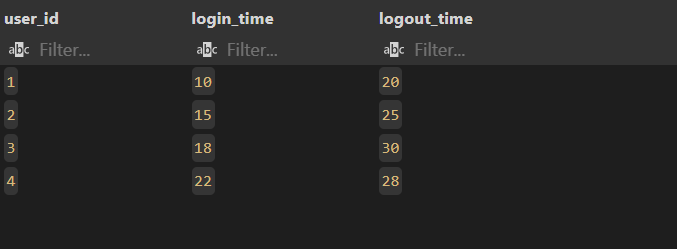

# Expected output:

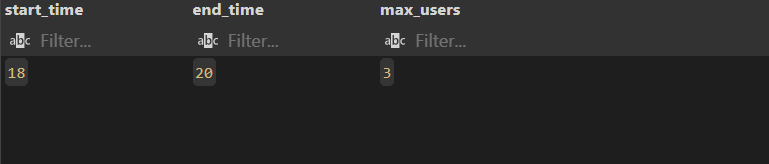

🧠 What each column means
user_id → unique user
login_time → when the user started being online
logout_time → when the user went offline

👉 Time is just a numeric scale (think of it as minutes or seconds).

📊 Timeline Breakdown

Let’s track how many users are online:

10 → 15 → User 1 → 1 user
15 → 18 → Users 1, 2 → 2 users
18 → 20 → Users 1, 2, 3 → 3 users
20 → 22 → Users 2, 3 → 2 users
22 → 25 → Users 2, 3, 4 → 🔥 3 users (peak)
25 → 28 → Users 3, 4 → 2 users
28 → 30 → User 3 → 1 user
✅ Key Insight
Maximum concurrent users = 3
This happens during:
18 → 20
22 → 25
📌 Final Expected Output